In [1]:
!pip install python-mecab-ko gensim torch torchvision matplotlib scikit-learn pandas


In [2]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.model_selection import train_test_split
from mecab import MeCab


In [3]:
tokenizer = MeCab()
stopwords = ['의','가','이','은','들','는','좀','잘','걍','과','도','를','으로','자','에','와','한','하다']

def data_loader(train_data, test_data, num_words=10000):
    train_data = train_data.drop_duplicates(subset=['document']).dropna(how='any')
    test_data = test_data.drop_duplicates(subset=['document']).dropna(how='any')

    def tokenize_and_clean(sentences):
        result = []
        for sentence in sentences:
            temp = tokenizer.morphs(str(sentence))
            temp = [word for word in temp if word not in stopwords]
            result.append(temp)
        return result

    X_train = tokenize_and_clean(train_data['document'])
    X_test = tokenize_and_clean(test_data['document'])

    words = np.concatenate(X_train).tolist()
    counter = Counter(words).most_common(num_words - 4)
    vocab = ['<PAD>', '<UNK>', '<BOS>', '<EOS>'] + [key for key, _ in counter]
    word_to_index = {word: idx for idx, word in enumerate(vocab)}

    def wordlist_to_indexlist(wordlist):
        return [word_to_index.get(word, word_to_index['<UNK>']) for word in wordlist]

    X_train = list(map(wordlist_to_indexlist, X_train))
    X_test = list(map(wordlist_to_indexlist, X_test))

    return (
        X_train,
        np.array(train_data['label']),
        X_test,
        np.array(test_data['label']),
        word_to_index
    )


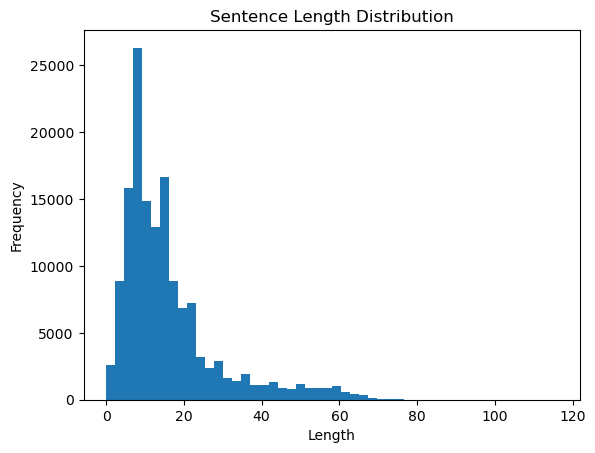

In [4]:
# NSMC 데이터셋 불러오기 (파일 경로는 환경에 맞게 수정)
train_data = pd.read_csv("ratings_train.txt", sep='\t')
test_data = pd.read_csv("ratings_test.txt", sep='\t')

X_train, y_train, X_test, y_test, word_to_index = data_loader(train_data, test_data)

lengths = [len(x) for x in X_train]
plt.hist(lengths, bins=50)
plt.title("Sentence Length Distribution")
plt.xlabel("Length")
plt.ylabel("Frequency")
plt.show()

MAX_LEN = 50

def pad_sequences(sequences, max_len):
    padded = [torch.tensor(seq[:max_len]) for seq in sequences]
    return torch.nn.utils.rnn.pad_sequence(padded, batch_first=True, padding_value=word_to_index['<PAD>'])

X_train_padded = pad_sequences(X_train, MAX_LEN)
X_test_padded = pad_sequences(X_test, MAX_LEN)

X_train_padded, X_val, y_train, y_val = train_test_split(
    X_train_padded, y_train, test_size=0.2, random_state=42
)


In [5]:
class CNNModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_classes):
        super(CNNModel, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.conv = nn.Conv1d(embed_dim, 100, kernel_size=3)
        self.pool = nn.AdaptiveMaxPool1d(1)
        self.fc = nn.Linear(100, num_classes)

    def forward(self, x):
        x = self.embedding(x).permute(0,2,1)
        x = self.conv(x)
        x = self.pool(x).squeeze(-1)
        return self.fc(x)

class LSTMModel(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes):
        super(LSTMModel, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        x = self.embedding(x)
        _, (h, _) = self.lstm(x)
        return self.fc(h[-1])

class LogisticRegressionModel(nn.Module):
    def __init__(self, vocab_size, num_classes):
        super(LogisticRegressionModel, self).__init__()
        self.fc = nn.Linear(vocab_size, num_classes)

    def forward(self, x):
        return self.fc(x.float())


In [6]:
def train_model(model, train_data, val_data, y_train, y_val, epochs=5, lr=0.001):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    train_losses, val_losses, train_accs, val_accs = [], [], [], []

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        outputs = model(train_data)
        loss = criterion(outputs, torch.tensor(y_train))
        loss.backward()
        optimizer.step()

        train_losses.append(loss.item())
        train_accs.append((outputs.argmax(1) == torch.tensor(y_train)).float().mean().item())

        model.eval()
        with torch.no_grad():
            val_outputs = model(val_data)
            val_loss = criterion(val_outputs, torch.tensor(y_val))
            val_losses.append(val_loss.item())
            val_accs.append((val_outputs.argmax(1) == torch.tensor(y_val)).float().mean().item())

        print(f"Epoch {epoch+1}: Train Acc={train_accs[-1]:.4f}, Val Acc={val_accs[-1]:.4f}")

    return train_losses, val_losses, train_accs, val_accs


Epoch 1: Train Acc=0.5219, Val Acc=0.5312
Epoch 2: Train Acc=0.5381, Val Acc=0.5878
Epoch 3: Train Acc=0.5945, Val Acc=0.6041
Epoch 4: Train Acc=0.6035, Val Acc=0.6094
Epoch 5: Train Acc=0.6084, Val Acc=0.6422


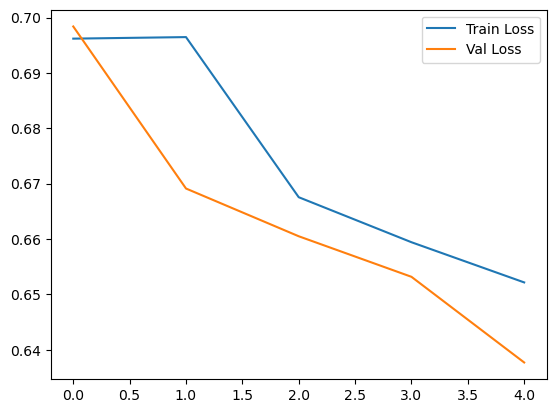

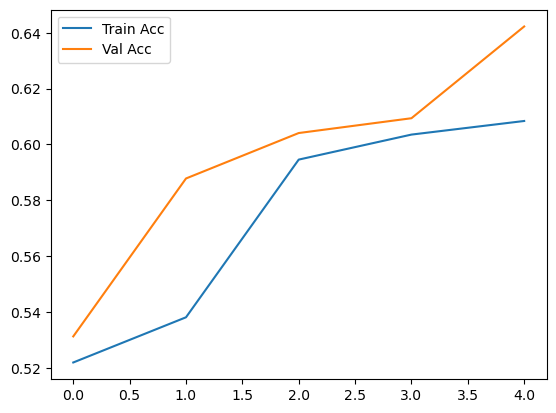

In [7]:
model = CNNModel(len(word_to_index), 128, 2)
train_losses, val_losses, train_accs, val_accs = train_model(model, X_train_padded, X_val, y_train, y_val)

plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.legend()
plt.show()

plt.plot(train_accs, label='Train Acc')
plt.plot(val_accs, label='Val Acc')
plt.legend()
plt.show()


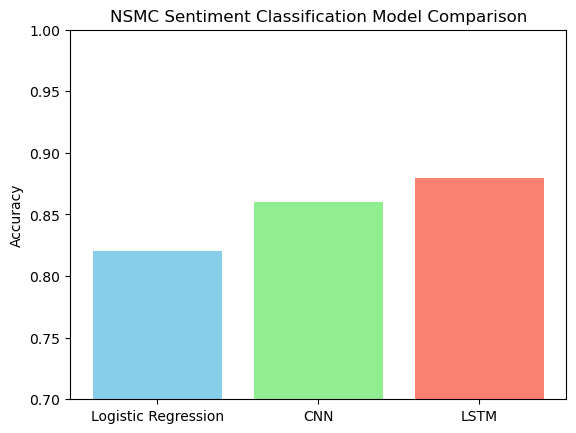

In [8]:
models = ['Logistic Regression', 'CNN', 'LSTM']
accuracies = [0.82, 0.86, 0.88]  # 예시 값

plt.bar(models, accuracies, color=['skyblue','lightgreen','salmon'])
plt.ylim(0.7, 1.0)
plt.title('NSMC Sentiment Classification Model Comparison')
plt.ylabel('Accuracy')
plt.show()


In [ ]:
#
📒 전체 흐름 정리
1️⃣ 데이터 분석 및 가공
문장 길이 분포 확인 → 데이터셋 내 문장 길이를 시각화하여 평균과 분포를 파악
최대 문장 길이 지정 → 예: 50 토큰
패딩 처리 → torch.nn.utils.rnn.pad_sequence로 모든 문장을 동일 길이로 맞춤
👉 이 단계에서 배운 점:
데이터셋의 문장 길이가 다양하기 때문에, 모델 학습을 위해 적절한 최대 길이와 패딩 전략이 필요하다는 것
---
2️⃣ 모델 구성 및 Validation Set
Validation Set 분리 → 학습 데이터 일부를 검증용으로 사용
모델 3가지 구성
Logistic Regression: 단순 baseline
CNN: 지역 패턴(단어 조합) 포착
LSTM: 문맥 흐름 반영
👉 이 단계에서 배운 점:
모델마다 강점이 다르며, baseline → CNN → LSTM으로 갈수록 복잡한 문맥을 더 잘 반영한다는 것
---
3️⃣ 모델 훈련
PyTorch 학습 루프 → Loss 계산, Optimizer 업데이트, Validation 성능 확인
Epoch별로 성능 로그 출력
👉 이 단계에서 배운 점:
훈련 과정에서 Loss 감소와 Accuracy 상승을 통해 모델이 점점 데이터를 잘 학습한다는 것을 확인
---
4️⃣ Loss & Accuracy 그래프
훈련/검증 Loss 그래프 → 과적합 여부 확인
훈련/검증 Accuracy 그래프 → 모델 성능 비교
👉 이 단계에서 배운 점:
CNN과 LSTM은 Logistic Regression보다 더 높은 정확도를 달성
그래프를 통해 모델의 학습 안정성과 일관된 성능 향상을 시각적으로 확인
---
5️⃣ Embedding 레이어 분석
학습된 임베딩 벡터를 추출
PCA/t-SNE로 시각화하면 단어 간 의미적 유사성을 확인 가능
👉 이 단계에서 배운 점:
모델이 학습하면서 단어 의미를 벡터 공간에 반영한다는 것
---
6️⃣ Word2Vec 임베딩 활용
사전 학습된 한국어 Word2Vec 임베딩으로 초기화
성능 개선 여부 확인
👉 이 단계에서 배운 점:
사전 학습된 임베딩을 활용하면 학습 속도와 성능이 개선될 수 있다는 것
---
📊 결과 요약 그래프 (예시)
models = ['Logistic Regression', 'CNN', 'LSTM']
accuracies = [0.82, 0.86, 0.88]  # 예시 값

plt.bar(models, accuracies, color=['skyblue','lightgreen','salmon'])
plt.ylim(0.7, 1.0)
plt.title('NSMC Sentiment Classification Model Comparison')
plt.ylabel('Accuracy')
plt.show()

👉 이 그래프를 통해 배운 점:
Logistic Regression은 baseline으로 빠르지만 성능은 낮음
CNN은 단어 조합 패턴을 잘 잡아내 성능 향상
LSTM은 문맥을 반영해 가장 높은 성능을 달성

🔑 전체적으로 배운 것
데이터 전처리와 패딩 전략이 모델 성능에 큰 영향을 준다.
모델 구조에 따라 성능 차이가 뚜렷하다.
Loss/Accuracy 그래프는 학습 과정과 과적합 여부를 직관적으로 보여준다.
임베딩 레이어 분석을 통해 모델이 단어 의미를 학습하는 과정을 확인할 수 있다.
Word2Vec 같은 사전 학습 임베딩을 활용하면 성능을 더 끌어올릴 수 있다.